# KPIs, Modelos Descriptivos y Predictivos — Retail BI

Notebook que **reconstruye las 10 imágenes de los KPIs** del dashboard y reproduce el
**análisis descriptivo de drivers** y los **modelos predictivos de demanda**
(Regresión Lineal y Random Forest) a partir de los Excel del proyecto.

**Fuentes:**
- `TIENDA RETAIL_LIMPIO.xlsx` — modelo relacional (factVentas y dimensiones)
- `ANALITICA PARA PBIX.xlsx` — comparativas y rankings usados en el dashboard
- `ANALISIS DESCRIPTIVO Y PREDICCION.xlsx` — salidas del análisis y modelos


In [1]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

# ==== CONFIGURACION (ajusta la ruta si el notebook se mueve) ====
BASE   = r'C:\Users\Usuario\Desktop\CURSOS\CURSO MIERCOLES'
XLSX   = BASE + r'\TIENDA RETAIL_LIMPIO.xlsx'
PBIX   = BASE + r'\ANALITICA PARA PBIX.xlsx'
DESC   = BASE + r'\ANALISIS DESCRIPTIVO Y PREDICCION.xlsx'
OUTIMG = BASE + r'\kpi_charts'
os.makedirs(OUTIMG, exist_ok=True)

AZUL = '#1F3864'
AZULC = '#0070C0'
CELESTE = '#5B9BD5'
GRIS = '#D9D9D9'
ROJO = '#C00000'
NARANJA = '#ED7D31'

plt.rcParams.update({'font.size': 12, 'axes.edgecolor': '#BBBBBB',
                     'axes.linewidth': 0.8, 'font.family': 'DejaVu Sans'})
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Set', 'Oct', 'Nov', 'Dic']

def style(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#E5E5E5', linewidth=0.8)
    ax.set_axisbelow(True)


In [2]:
# ============ CARGA DE DATOS ============
fact = pd.read_excel(XLSX, sheet_name='factVentas')
dimP = pd.read_excel(XLSX, sheet_name='dimProducto')
dimT = pd.read_excel(XLSX, sheet_name='dimTienda')
dimTi = pd.read_excel(XLSX, sheet_name='dimTiempo')
dimC = pd.read_excel(XLSX, sheet_name='dimContexto')
dimPr = pd.read_excel(XLSX, sheet_name='dimPromocion')

fact['VentasNetas'] = fact['Unidad_Vendida'] * fact['Precio'] * (1 - fact['Descuento'] / 100.0)
f = (fact.merge(dimP[['Producto_SK', 'Categoria']], on='Producto_SK', how='left')
         .merge(dimT[['Tienda_SK', 'Region']], on='Tienda_SK', how='left'))

anual   = pd.read_excel(PBIX, sheet_name='Comparativa Anual')
mensual = pd.read_excel(PBIX, sheet_name='Comparativa Mensual')
top_tiendas  = pd.read_excel(PBIX, sheet_name='Top Tiendas')
top_prods    = pd.read_excel(PBIX, sheet_name='Top Productos')
mes = pd.read_excel(DESC, sheet_name='Mes')

print('filas factVentas:', len(fact))
print('Ventas netas totales: $%.1f M' % (f.VentasNetas.sum() / 1e6))
print('Unidades totales: %s' % f'{f.Unidad_Vendida.sum():,}')
print('Promedio diario: ${:,.0f}'.format(f.groupby('Fecha_SK').VentasNetas.sum().mean()))
print('Descuento promedio: %.1f%%' % f.Descuento.mean())
print('Inventario promedio: %.0f uds' % f.Nivel_Inventario.mean())
print('Demanda promedio: %.0f uds' % f.Demanda.mean())
print('Top tienda: %s' % f.groupby('Region').VentasNetas.sum().nlargest(1).round(1).to_dict())


filas factVentas: 76000
Ventas netas totales: $412.6 M
Unidades totales: 6,750,876
Promedio diario: $542,882
Descuento promedio: 9.1%
Inventario promedio: 301 uds
Demanda promedio: 104 uds
Top tienda: {'North': 154144375.8}


---
## PARTE 1 — LAS 10 IMÁGENES DE LOS KPIs

Genera cada gráfico del dashboard (mismo estilo del informe final). Cada gráfico se **muestra aquí mismo** y también se guarda en `kpi_charts\`.


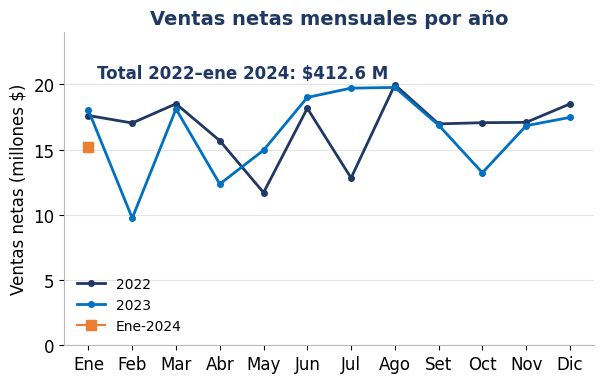

OK kpi_ventas_mes.png


In [3]:
# ---- KPI 1: Ventas netas mensuales por año (Total 2022–ene 2024: $412.6 M) ----
m = mensual.copy()
m.columns = [str(c) for c in m.columns]
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(meses, m['2022'] / 1e6, color=AZUL, linewidth=2, marker='o', markersize=4, label='2022')
ax.plot(meses, m['2023'] / 1e6, color=AZULC, linewidth=2, marker='o', markersize=4, label='2023')
ax.plot(['Ene'], m['2024'][0] / 1e6, color=NARANJA, marker='s', markersize=7, label='Ene-2024')
ax.text(0.2, 20.5, 'Total 2022–ene 2024: $412.6 M', fontsize=12, fontweight='bold', color=AZUL)
ax.legend(frameon=False, fontsize=10)
ax.set_ylabel('Ventas netas (millones $)')
ax.set_title('Ventas netas mensuales por año', fontweight='bold', color=AZUL, fontsize=14)
style(ax); ax.set_ylim(0, 24)
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_ventas_mes.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_ventas_mes.png')

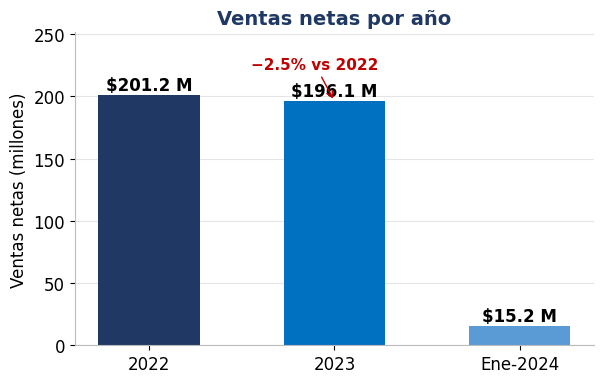

OK kpi_ventas_2023.png


In [4]:
# ---- KPI 2: Ventas netas por año (2023 −2.5% vs 2022) ----
v = anual.set_index('Año')['Ventas Netas']
labels = ['2022', '2023', 'Ene-2024']
vals = [v[2022] / 1e6, v[2023] / 1e6, v[2024] / 1e6]
fig, ax = plt.subplots(figsize=(6.2, 4))
b = ax.bar(labels, vals, color=[AZUL, AZULC, CELESTE], width=0.55)
for r, val in zip(b, vals):
    ax.text(r.get_x() + r.get_width() / 2, val + 4, f'${val:.1f} M', ha='center', fontsize=12, fontweight='bold')
ax.annotate('−2.5% vs 2022', xy=(1, vals[1]), xytext=(0.55, vals[1] + 26),
            fontsize=11, color=ROJO, fontweight='bold', arrowprops=dict(arrowstyle='->', color=ROJO))
ax.set_ylabel('Ventas netas (millones)')
ax.set_title('Ventas netas por año', fontweight='bold', color=AZUL, fontsize=14)
style(ax); ax.set_ylim(0, max(vals) * 1.25)
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_ventas_2023.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_ventas_2023.png')

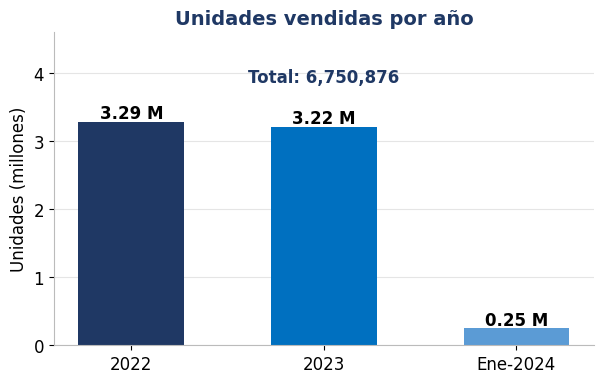

OK kpi_unidades.png


In [5]:
# ---- KPI 3: Unidades vendidas por año (Total: 6,750,876) ----
u = anual.set_index('Año')['Unidades Vendidas']
uvals = [u[2022] / 1e6, u[2023] / 1e6, u[2024] / 1e6]
fig, ax = plt.subplots(figsize=(6.2, 4))
b = ax.bar(['2022', '2023', 'Ene-2024'], uvals, color=[AZUL, AZULC, CELESTE], width=0.55)
for r, val in zip(b, uvals):
    ax.text(r.get_x() + r.get_width() / 2, val + 0.05, f'{val:.2f} M', ha='center', fontsize=12, fontweight='bold')
ax.text(1, max(uvals) * 1.18, 'Total: 6,750,876', ha='center', fontsize=12, fontweight='bold', color=AZUL)
ax.set_ylabel('Unidades (millones)')
ax.set_title('Unidades vendidas por año', fontweight='bold', color=AZUL, fontsize=14)
style(ax); ax.set_ylim(0, max(uvals) * 1.4)
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_unidades.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_unidades.png')

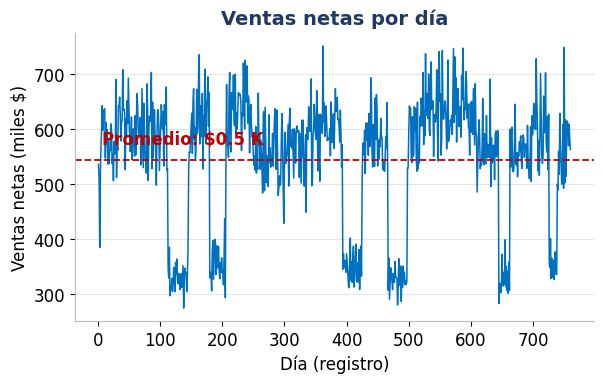

OK kpi_diario.png


In [6]:
# ---- KPI 4: Ventas netas diarias (promedio $542,882) ----
diario = f.groupby('Fecha_SK').VentasNetas.sum() / 1e3
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(diario.index, diario.values, color=AZULC, linewidth=1.1)
prom = diario.mean()
ax.axhline(prom, color=ROJO, linestyle='--', linewidth=1.3)
ax.text(diario.index.min() + 5, prom + 30, f'Promedio: ${prom/1e3:,.1f} K', color=ROJO, fontsize=12, fontweight='bold')
ax.set_xlabel('Día (registro)')
ax.set_ylabel('Ventas netas (miles $)')
ax.set_title('Ventas netas por día', fontweight='bold', color=AZUL, fontsize=14)
style(ax)
ax.get_yaxis().set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_diario.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_diario.png')

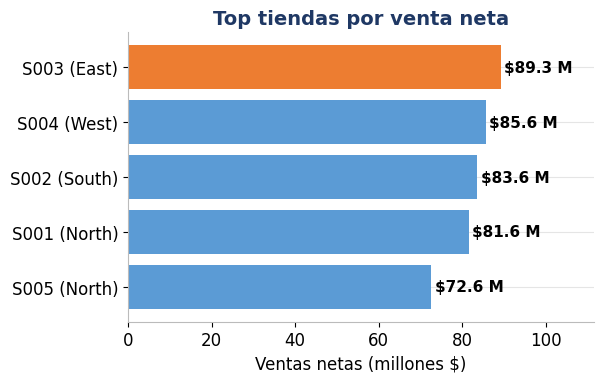

OK kpi_top_tienda.png


In [7]:
# ---- KPI 5: Top tienda (S003 East, $89.3 M, 21.6%) ----
tt = top_tiendas.sort_values('Ventas_Netas')
labels = tt['Store ID'] + ' (' + tt['Region'] + ')'
vals = tt['Ventas_Netas'] / 1e6
colors = [NARANJA if s == 'S003' else CELESTE for s in tt['Store ID']]
fig, ax = plt.subplots(figsize=(6.2, 4))
b = ax.barh(labels, vals, color=colors)
for r, val, sid in zip(b, vals, tt['Store ID']):
    ax.text(val + 0.8, r.get_y() + r.get_height() / 2, f'${val:.1f} M', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Ventas netas (millones $)')
ax.set_title('Top tiendas por venta neta', fontweight='bold', color=AZUL, fontsize=14)
style(ax); ax.set_xlim(0, vals.max() * 1.25)
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_top_tienda.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_top_tienda.png')

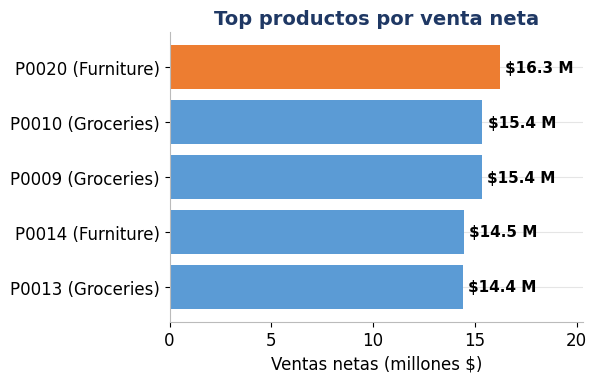

OK kpi_top_producto.png


In [8]:
# ---- KPI 6: Top producto (P0020 Furniture, $16.3 M) ----
tp = top_prods.head(5).sort_values('Ventas_Netas')
labels = tp['Product ID'] + ' (' + tp['Categoria'] + ')'
vals = tp['Ventas_Netas'] / 1e6
colors = [NARANJA if s == 'P0020' else CELESTE for s in tp['Product ID']]
fig, ax = plt.subplots(figsize=(6.2, 4))
b = ax.barh(labels, vals, color=colors)
for r, val in zip(b, vals):
    ax.text(val + 0.25, r.get_y() + r.get_height() / 2, f'${val:.1f} M', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Ventas netas (millones $)')
ax.set_title('Top productos por venta neta', fontweight='bold', color=AZUL, fontsize=14)
style(ax); ax.set_xlim(0, vals.max() * 1.25)
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_top_producto.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_top_producto.png')

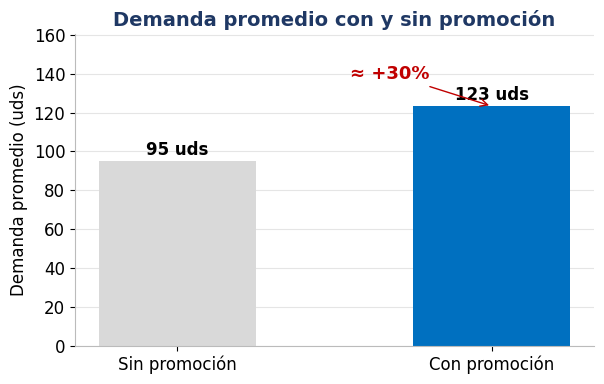

OK kpi_promocion.png


In [9]:
# ---- KPI 7: Efecto de la promoción (123 vs 95 ≈ +30%) ----
pr = pd.read_excel(DESC, sheet_name='Promocion')
dvals = [pr.loc[pr['Descripcion'] == 'Sin promoción', 'Demanda_Promedio'].iloc[0],
         pr.loc[pr['Descripcion'] == 'Con promoción', 'Demanda_Promedio'].iloc[0]]
fig, ax = plt.subplots(figsize=(6.2, 4))
b = ax.bar(['Sin promoción', 'Con promoción'], dvals, color=[GRIS, AZULC], width=0.5)
for r, val in zip(b, dvals):
    ax.text(r.get_x() + r.get_width() / 2, val + 3, f'{val:.0f} uds', ha='center', fontsize=12, fontweight='bold')
ax.annotate('≈ +30%', xy=(1, dvals[1]), xytext=(0.55, dvals[1] + 14), fontsize=13, fontweight='bold',
            color=ROJO, arrowprops=dict(arrowstyle='->', color=ROJO))
ax.set_ylabel('Demanda promedio (uds)')
ax.set_title('Demanda promedio con y sin promoción', fontweight='bold', color=AZUL, fontsize=14)
style(ax); ax.set_ylim(0, max(dvals) * 1.3)
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_promocion.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_promocion.png')

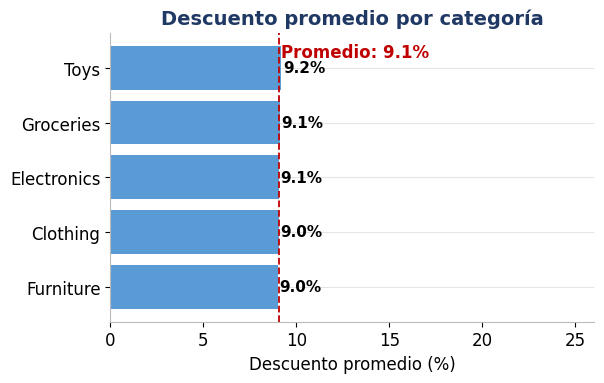

OK kpi_descuento.png


In [10]:
# ---- KPI 8: Descuento promedio (9.1%) ----
descuento = f.groupby('Categoria')['Descuento'].mean().sort_values()
fig, ax = plt.subplots(figsize=(6.2, 4))
b = ax.barh(descuento.index, descuento.values, color=CELESTE)
for r, val in zip(b, descuento.values):
    ax.text(val + 0.1, r.get_y() + r.get_height() / 2, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.axvline(f.Descuento.mean(), color=ROJO, linestyle='--', linewidth=1.3)
ax.text(f.Descuento.mean() + 0.1, 4.2, f'Promedio: {f.Descuento.mean():.1f}%', color=ROJO, fontsize=12, fontweight='bold')
ax.set_xlabel('Descuento promedio (%)')
ax.set_title('Descuento promedio por categoría', fontweight='bold', color=AZUL, fontsize=14)
style(ax); ax.set_xlim(0, f.Descuento.max() + 1)
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_descuento.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_descuento.png')

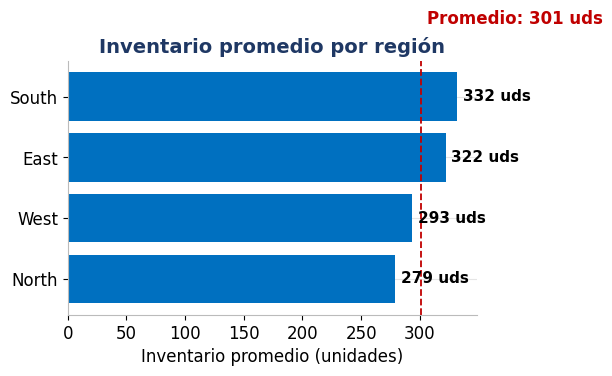

OK kpi_inventario.png


In [11]:
# ---- KPI 9: Inventario promedio (301 uds) ----
inv = f.groupby('Region')['Nivel_Inventario'].mean().sort_values()
fig, ax = plt.subplots(figsize=(6.2, 4))
b = ax.barh(inv.index, inv.values, color=AZULC)
for r, val in zip(b, inv.values):
    ax.text(val + 5, r.get_y() + r.get_height() / 2, f'{val:.0f} uds', va='center', fontsize=11, fontweight='bold')
ax.axvline(f.Nivel_Inventario.mean(), color=ROJO, linestyle='--', linewidth=1.3)
ax.text(f.Nivel_Inventario.mean() + 5, 4.2, f'Promedio: {f.Nivel_Inventario.mean():.0f} uds', color=ROJO, fontsize=12, fontweight='bold')
ax.set_xlabel('Inventario promedio (unidades)')
ax.set_title('Inventario promedio por región', fontweight='bold', color=AZUL, fontsize=14)
style(ax)
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_inventario.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_inventario.png')

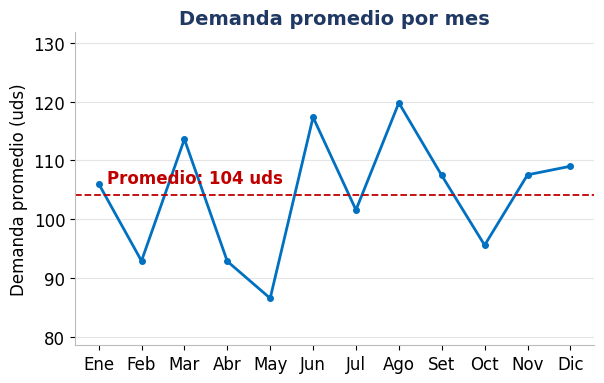

OK kpi_demanda.png

Imágenes generadas: 10


In [12]:
# ---- KPI 10: Demanda promedio (104 uds) ----
fig, ax = plt.subplots(figsize=(6.2, 4))
ax.plot(meses, mes['Demanda_Promedio'], color=AZULC, linewidth=2, marker='o', markersize=4)
prom_d = mes['Demanda_Promedio'].mean()
ax.axhline(prom_d, color=ROJO, linestyle='--', linewidth=1.3)
ax.text(0.2, prom_d + 2, f'Promedio: {prom_d:.0f} uds', color=ROJO, fontsize=12, fontweight='bold')
ax.set_ylabel('Demanda promedio (uds)')
ax.set_title('Demanda promedio por mes', fontweight='bold', color=AZUL, fontsize=14)
style(ax); ax.set_ylim(mes['Demanda_Promedio'].min() - 8, mes['Demanda_Promedio'].max() + 12)
fig.tight_layout(); fig.savefig(OUTIMG + r'\kpi_demanda.png', dpi=160)
plt.show(); plt.close(fig)
print('OK kpi_demanda.png')

import glob
print()
print('Imágenes generadas:', len(glob.glob(OUTIMG + r'\*.png')))

---
## PARTE 2 — MODELO DESCRIPTIVO (drivers de la demanda)

Evalúa qué variables explican la demanda: correlaciones, promoción, clima, estacionalidad, mes, categoría y su combinación promoción × categoría.


In [13]:
# ============ DESCRIPTIVO: DRIVERS DE LA DEMANDA ============
dm = f.merge(dimTi, on='Fecha_SK').merge(dimC, on='Contexto_SK').merge(dimPr, on='Promocion_SK')
dm['Ventas Netas'] = dm['VentasNetas']

corr_cols = ['Demanda', 'Precio', 'Descuento', 'Precio_Competencia',
             'Nivel_Inventario', 'Unidades_Ordenadas', 'Unidad_Vendida', 'Ventas Netas']
corr = dm[corr_cols].corr().round(3)
corr_demanda = corr['Demanda'].drop('Demanda').reset_index()
corr_demanda.columns = ['Variable', 'Correlacion con Demanda']
corr_demanda = corr_demanda.sort_values('Correlacion con Demanda', ascending=False)
corr_demanda

,Variable,Correlacion con Demanda
5,Unidad_Vendida,0.833
4,Unidades_Ordenadas,0.512
6,Ventas Netas,0.470
1,Descuento,0.225
3,Nivel_Inventario,0.127
2,Precio_Competencia,-0.023
0,Precio,-0.023


In [14]:
resumen_promo = dm.groupby('Descripcion').agg(
    Demanda_Promedio=('Demanda', 'mean'),
    Unidades_Vendidas_Promedio=('Unidad_Vendida', 'mean'),
    Precio_Promedio=('Precio', 'mean')).round(2).reset_index()
resumen_clima = dm.groupby('Condiciones Climaticas').agg(
    Demanda_Promedio=('Demanda', 'mean'),
    Unidades_Vendidas_Promedio=('Unidad_Vendida', 'mean'),
    Ventas_Netas=('Ventas Netas', 'sum')).round(2).reset_index().sort_values('Demanda_Promedio', ascending=False)
resumen_estacion = dm.groupby('Estacionalidad').agg(
    Demanda_Promedio=('Demanda', 'mean'),
    Unidades_Vendidas_Promedio=('Unidad_Vendida', 'mean'),
    Ventas_Netas=('Ventas Netas', 'sum')).round(2).reset_index().sort_values('Demanda_Promedio', ascending=False)
resumen_categoria = dm.groupby('Categoria').agg(
    Demanda_Promedio=('Demanda', 'mean'),
    Unidades_Vendidas_Promedio=('Unidad_Vendida', 'mean'),
    Ventas_Netas=('Ventas Netas', 'sum')).round(2).reset_index().sort_values('Demanda_Promedio', ascending=False)
promo_x_cat = dm.groupby(['Categoria', 'Descripcion'])['Demanda'].mean().round(2).unstack().reset_index()

print('=== PROMOCION ===');       print(resumen_promo.to_string(index=False))
print(); print('=== CLIMA ===');   print(resumen_clima.to_string(index=False))
print(); print('=== ESTACIONALIDAD ==='); print(resumen_estacion.to_string(index=False))
print(); print('=== CATEGORIA ==='); print(resumen_categoria.to_string(index=False))
print(); print('=== PROMO x CATEGORIA ==='); print(promo_x_cat.to_string(index=False))

=== PROMOCION ===
  Descripcion  Demanda_Promedio  Unidades_Vendidas_Promedio  Precio_Promedio
Con promoción            123.27                      103.10            65.30
Sin promoción             95.03                       81.83            68.92

=== CLIMA ===
Condiciones Climaticas  Demanda_Promedio  Unidades_Vendidas_Promedio  Ventas_Netas
                 Sunny            115.17                       97.03  141610354.46
                Cloudy            105.40                       89.63  133331734.31
                 Rainy             95.11                       81.97   83903959.30
                 Snowy             94.05                       80.95   53744541.75

=== ESTACIONALIDAD ===
Estacionalidad  Demanda_Promedio  Unidades_Vendidas_Promedio  Ventas_Netas
        Summer            112.86                       95.76  109493224.97
        Autumn            103.42                       88.46   98100428.87
        Winter            103.41                       87.77  113627259.

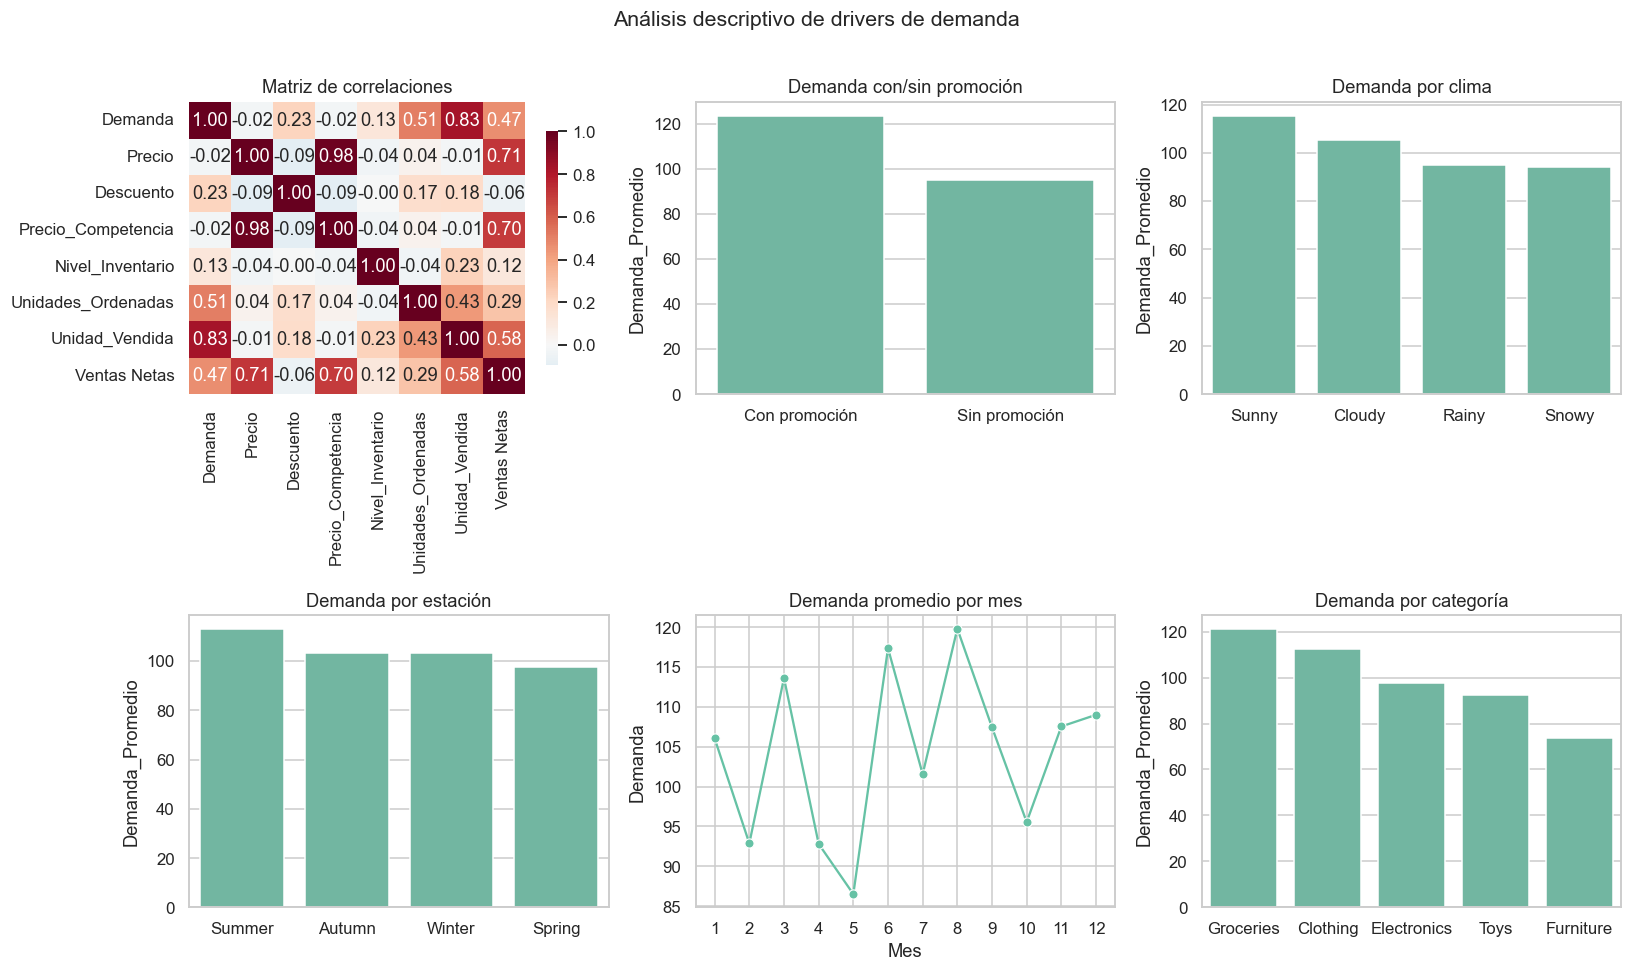

OK GRAFICO_DRIVERS.png


In [15]:
# ============ GRAFICO DE DRIVERS ============
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Análisis descriptivo de drivers de demanda', fontsize=14)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0, 0],
            cbar_kws={'shrink': .8}); axes[0, 0].set_title('Matriz de correlaciones')
sns.barplot(data=resumen_promo, x='Descripcion', y='Demanda_Promedio', ax=axes[0, 1])
axes[0, 1].set_title('Demanda con/sin promoción'); axes[0, 1].set_xlabel('')
sns.barplot(data=resumen_clima, x='Condiciones Climaticas', y='Demanda_Promedio', ax=axes[0, 2])
axes[0, 2].set_title('Demanda por clima'); axes[0, 2].set_xlabel('')
sns.barplot(data=resumen_estacion, x='Estacionalidad', y='Demanda_Promedio', ax=axes[1, 0])
axes[1, 0].set_title('Demanda por estación'); axes[1, 0].set_xlabel('')
sns.lineplot(data=dm.groupby('Mes').Demanda.mean().reset_index(), x='Mes', y='Demanda', marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Demanda promedio por mes'); axes[1, 1].set_xticks(range(1, 13))
sns.barplot(data=resumen_categoria, x='Categoria', y='Demanda_Promedio', ax=axes[1, 2])
axes[1, 2].set_title('Demanda por categoría'); axes[1, 2].set_xlabel('')
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(BASE + r'\GRAFICO_DRIVERS.png', bbox_inches='tight')
plt.show(); plt.close(fig)
print('OK GRAFICO_DRIVERS.png')

---
## PARTE 3 — MODELO PREDICTIVO DE DEMANDA

Entrena **Regresión Lineal** y **Random Forest** con los datos 2022–2023 y valida con **enero 2024** (datos nuevos que el modelo nunca vio).


In [16]:
# ============ PREDICTIVO: PREPARACION ============
features = ['Precio', 'Descuento', 'Precio_Competencia', 'Nivel_Inventario',
            'Unidades_Ordenadas', 'Promoción', 'Epidemic', 'Mes', 'Año']
dm = (fact.merge(dimTi, on='Fecha_SK').merge(dimC, on='Contexto_SK')
          .merge(dimP, on='Producto_SK').merge(dimT, on='Tienda_SK')
          .merge(dimPr, on='Promocion_SK'))
dm['Ventas Netas'] = dm['Unidad_Vendida'] * dm['Precio'] * (1 - dm['Descuento'] / 100)

X = dm[features + ['Condiciones Climaticas', 'Estacionalidad', 'Categoria', 'Region']].copy()
X = pd.get_dummies(X, columns=['Condiciones Climaticas', 'Estacionalidad', 'Categoria', 'Region'])
y = dm['Demanda']

train = dm['Año'] < 2024
X_tr, X_te = X[train], X[~train]
y_tr, y_te = y[train], y[~train]
print(f'Entrenamiento: {len(y_tr):,} registros | Validación (ene 2024): {len(y_te):,} registros')

Entrenamiento: 73,000 registros | Validación (ene 2024): 3,000 registros


In [17]:
# ============ ENTRENAMIENTO Y METRICAS ============
r_lr = LinearRegression().fit(X_tr, y_tr)
r_rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_tr, y_tr)

resultados = []
preds = {}
for nombre, m in [('Regresion Lineal', r_lr), ('Random Forest', r_rf)]:
    p = m.predict(X_te)
    preds[nombre] = p
    resultados.append({'Modelo': nombre,
                       'MAE': round(mean_absolute_error(y_te, p), 2),
                       'RMSE': round(np.sqrt(mean_squared_error(y_te, p)), 2),
                       'R2': round(r2_score(y_te, p), 4),
                       'Demanda Promedio Real': round(y_te.mean(), 2),
                       'Demanda Promedio Predicha': round(p.mean(), 2)})
df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,MAE,RMSE,R2,Demanda Promedio Real,Demanda Promedio Predicha
0,Regresion Lineal,23.25,30.30,0.5528,98.05,101.06
1,Random Forest,16.64,23.27,0.7362,98.05,100.22


In [18]:
# ============ IMPORTANCIA Y COEFICIENTES ============
importancia = pd.DataFrame({'Variable': X_tr.columns,
                            'Importancia RandomForest': r_rf.feature_importances_}).round(4)
importancia = importancia.sort_values('Importancia RandomForest', ascending=False)

coefs = pd.DataFrame({'Variable': X_tr.columns, 'Coef Lineal': r_lr.coef_}).round(4)
coefs['Abs Coef'] = coefs['Coef Lineal'].abs()
coefs = coefs.sort_values('Abs Coef', ascending=False).drop(columns='Abs Coef')

print('=== TOP 10 IMPORTANCIA (RANDOM FOREST) ===')
print(importancia.head(10).to_string(index=False))
print()
print('=== TOP 10 COEFICIENTES (REGRESION LINEAL) ===')
print(coefs.head(10).to_string(index=False))

=== TOP 10 IMPORTANCIA (RANDOM FOREST) ===
           Variable  Importancia RandomForest
 Unidades_Ordenadas                    0.3372
             Precio                    0.1218
           Epidemic                    0.0992
   Nivel_Inventario                    0.0777
Categoria_Groceries                    0.0771
 Precio_Competencia                    0.0637
Categoria_Furniture                    0.0355
          Promoción                    0.0351
 Categoria_Clothing                    0.0209
          Descuento                    0.0203

=== TOP 10 COEFICIENTES (REGRESION LINEAL) ===
                    Variable  Coef Lineal
         Categoria_Furniture     -39.7028
                    Epidemic     -35.3585
         Categoria_Groceries      25.0503
                   Promoción      19.0185
          Categoria_Clothing      11.7101
Condiciones Climaticas_Sunny       8.9636
              Categoria_Toys       8.2005
Condiciones Climaticas_Snowy      -5.3135
Condiciones Climaticas_Ra

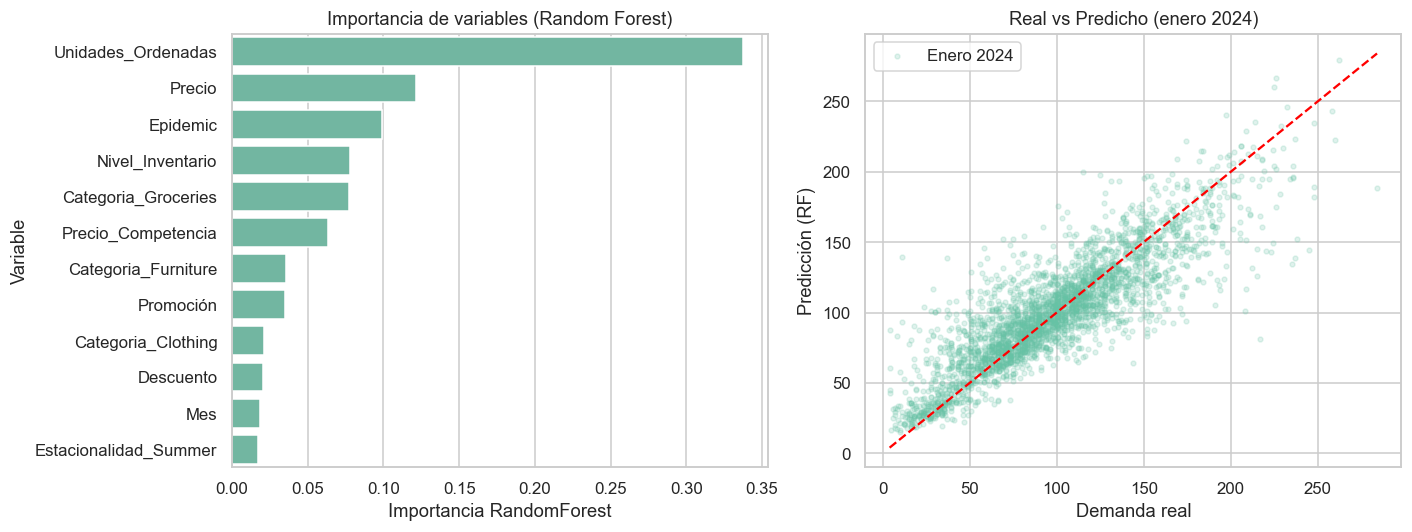

OK GRAFICO_MODELO.png

=== RESULTADOS MODELO ===
          Modelo   MAE  RMSE     R2  Demanda Promedio Real  Demanda Promedio Predicha
Regresion Lineal 23.25 30.30 0.5528                  98.05                     101.06
   Random Forest 16.64 23.27 0.7362                  98.05                     100.22


In [19]:
# ============ GRAFICO DEL MODELO ============
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=importancia.head(12), x='Importancia RandomForest', y='Variable', ax=axes[0])
axes[0].set_title('Importancia de variables (Random Forest)')
ax = axes[1]
pred_df = pd.DataFrame({'Fecha': dm.loc[~train, 'Fecha'], 'Demanda Real': y_te.values,
                        'Prediccion RF': preds['Random Forest'].round(1)})
ax.scatter(pred_df['Demanda Real'], pred_df['Prediccion RF'], alpha=0.2, s=10, label='Enero 2024')
lim = [pred_df['Demanda Real'].min(), pred_df['Demanda Real'].max()]
ax.plot(lim, lim, 'r--')
ax.set_xlabel('Demanda real'); ax.set_ylabel('Predicción (RF)')
ax.set_title('Real vs Predicho (enero 2024)'); ax.legend()
fig.tight_layout()
fig.savefig(BASE + r'\GRAFICO_MODELO.png', bbox_inches='tight')
plt.show(); plt.close(fig)
print('OK GRAFICO_MODELO.png')
print()
print('=== RESULTADOS MODELO ===')
print(df_resultados.to_string(index=False))

---
## PARTE 4 — PREDICCIÓN DIARIA (enero 2024) y EXPORTACIÓN

Deja las predicciones día a día y exporta todos los resultados a un solo Excel.


In [20]:
# ============ PREDICCION DIARIA ============
pred_df = pd.DataFrame({'Fecha': dm.loc[~train, 'Fecha'],
                        'Product ID': dm.loc[~train, 'Product ID'],
                        'Store ID': dm.loc[~train, 'Store ID'],
                        'Demanda Real': y_te.values,
                        'Prediccion RF': preds['Random Forest'].round(1),
                        'Prediccion LR': preds['Regresion Lineal'].round(1)})
pred_diaria = pred_df.groupby('Fecha').agg(Demanda_Real=('Demanda Real', 'mean'),
                                           Prediccion_RF=('Prediccion RF', 'mean'),
                                           Prediccion_LR=('Prediccion LR', 'mean')).round(1).reset_index()
pred_diaria.head(15)

,Fecha,Demanda_Real,Prediccion_RF,Prediccion_LR
0,2024-01-01,69.3,71.0,71.5
1,2024-01-02,71.8,71.8,70.1
2,2024-01-03,71.1,72.8,69.7
3,2024-01-04,64.3,68.8,68.1
4,2024-01-05,77.1,80.4,83.7
5,2024-01-06,73.0,72.2,70.5
6,2024-01-07,69.5,70.9,68.5
7,2024-01-08,71.4,72.8,74.1
8,2024-01-09,100.8,108.7,109.6
9,2024-01-10,100.6,109.1,111.0


In [21]:
# ============ EXPORTAR RESULTADOS ============
SALIDA_XLSX = BASE + r'\ANALISIS DESCRIPTIVO Y PREDICCION (notebook).xlsx'
with pd.ExcelWriter(SALIDA_XLSX, engine='openpyxl') as w:
    corr_demanda.to_excel(w, sheet_name='Correlaciones', index=False)
    resumen_promo.to_excel(w, sheet_name='Promocion', index=False)
    resumen_clima.to_excel(w, sheet_name='Clima', index=False)
    resumen_estacion.to_excel(w, sheet_name='Estacionalidad', index=False)
    resumen_categoria.to_excel(w, sheet_name='Categoria', index=False)
    promo_x_cat.to_excel(w, sheet_name='Promo x Categoria', index=False)
    df_resultados.to_excel(w, sheet_name='Resultados Modelo', index=False)
    importancia.to_excel(w, sheet_name='Importancia Variables', index=False)
    coefs.to_excel(w, sheet_name='Coeficientes Lineales', index=False)
    pred_df.sample(500, random_state=42).to_excel(w, sheet_name='Predicciones Muestra', index=False)
    pred_diaria.to_excel(w, sheet_name='Prediccion Diaria', index=False)
print('Exportado:', SALIDA_XLSX)

Exportado: C:\Users\Usuario\Desktop\CURSOS\CURSO MIERCOLES\ANALISIS DESCRIPTIVO Y PREDICCION (notebook).xlsx
